# CAMS (EAC4 + NRT) – Eindhoven (0.75° / native grid)

**Goal:** Prepare CAMS atmospheric variables for the solar radiation project.

- Download daily CAMS EAC4 reanalysis (historical) for Eindhoven: total cloud cover (tcc), aerosol optical depth at 550 nm (aod550), total column water vapour (tcwv)
- Download daily CAMS NRT analyses (near-real-time) for Eindhoven: aod550, tcwv (no tcc in this product)
- Convert each day to a daily mean and save small NetCDF files.

**Input**

- CAMS EAC4 (cams-global-reanalysis-eac4) via CDS API.
- CAMS NRT (cams-global-atmospheric-composition-forecasts) via ADS.

**Output**

- Daily mean EAC4 files:
    data/CAMS_Daily/cams_eac4_YYYY-MM-DD_daily.nc
    (variables: tcc, aod550, tcwv over a small Eindhoven box)

- Daily mean NRT files:
    data/CAMS_Daily/cams_nrt_YYYY-MM-DD_daily.nc
    (variables: aod550, tcwv over a small Eindhoven box)

These files can later be:
- merged with SARAH-3 SIS (0.05° grid),
- combined with DEM/terrain features,
- used as predictors for solar radiation models.

## 1. Setup folders & imports

In [1]:
from pathlib import Path
from datetime import date, timedelta
import re

import cdsapi
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt 

# CDS API client
c = cdsapi.Client()

# Output folders
CAMS_DIR = Path("data/CAMS_Daily")
CAMS_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR = CAMS_DIR / "raw"
RAW_DIR.mkdir(exist_ok=True)

print("CAMS output folder:", CAMS_DIR)
print("Raw downloads folder:", RAW_DIR)


2025-12-12 15:42:50,715 INFO [2025-12-03T00:00:00Z] To improve our CAMS service, we need to hear from you! Please complete this very short [survey]( https://confluence.ecmwf.int/x/CruBEQ/). Thank you.


CAMS output folder: data\CAMS_Daily
Raw downloads folder: data\CAMS_Daily\raw


## 2. CAMS variables used in this project

We focus on three atmospheric variables from CAMS:

1) tcc – total cloud cover
   - CAMS name: "total_cloud_cover"
   - Unit: 0–1 (fraction)
   - 0.0  → clear sky
     1.0  → fully overcast
   - Interpretation: Clouds block/scatter sunlight → strong impact on surface radiation.

2) aod550 – total aerosol optical depth at 550 nm
   - CAMS name: "total_aerosol_optical_depth_550nm"
   - Unit: dimensionless
   - Typical values:
        - ~0.05 → very clean air
        - ~0.2  → moderate aerosols (normal for NL)
        - more than 0.4  → very hazy / dusty
   - Interpretation: Aerosols (dust, smoke, pollution) reduce direct sunlight but can increase diffuse light.

3) tcwv – total column water vapour
   - CAMS name: "total_column_water_vapour"
   - Unit: kg/m² (similar to mm of precipitable water)
   - Interpretation: Total water vapour in the whole atmospheric column. Important for humidity, clouds and longwave radiation.

**=> Simple explanation:**

    - tcc   → "How cloudy is the sky?"
    - aod550 → "How hazy / polluted is the air for sunlight?"
    - tcwv  → "How moist is the total air column?"

Eindhoven domain:
- Latitude: 51–52°N
- Longitude: 5–6°E

# 3. Helper: download + daily mean for ONE day

In [2]:
def download_cams_daily(d: date, mode: str = "reanalysis", force_daily_rebuild: bool = False):
    """
    Create a daily-mean CAMS file for date d.
    - If raw file exists: uses it (no download).
    - If raw missing: downloads it.
    - Always writes a daily file with a proper time dimension: time=[d]
    """

    if mode == "reanalysis":
        dataset = "cams-global-reanalysis-eac4"
        raw_file   = RAW_DIR  / f"cams_eac4_{d:%Y-%m-%d}_raw.nc"
        daily_file = CAMS_DIR / f"cams_eac4_{d:%Y-%m-%d}_daily.nc"

        request = {
            "format": "netcdf",
            "variable": [
                "total_cloud_cover",
                "total_aerosol_optical_depth_550nm",
                "total_column_water_vapour",
            ],
            "date": f"{d:%Y-%m-%d}/{d:%Y-%m-%d}",
            "time": ["00:00","03:00","06:00","09:00","12:00","15:00","18:00","21:00"],
            "area": [52.0, 5.0, 51.0, 6.0],
            "grid": "0.75/0.75",
        }

    elif mode == "forecast":
        dataset = "cams-global-atmospheric-composition-forecasts"
        raw_file   = RAW_DIR  / f"cams_nrt_{d:%Y-%m-%d}_raw.nc"
        daily_file = CAMS_DIR / f"cams_nrt_{d:%Y-%m-%d}_daily.nc"

        request = {
            "format": "netcdf",
            "variable": [
                "total_aerosol_optical_depth_550nm",
                "total_column_water_vapour",
            ],
            "date": f"{d:%Y-%m-%d}",
            "time": ["00:00","06:00","12:00","18:00"],
            "leadtime_hour": "0",
            "type": "analysis",
            "area": [52.0, 5.0, 51.0, 6.0],
        }
    else:
        raise ValueError("mode must be 'reanalysis' or 'forecast'")

    # daily exists?
    if daily_file.exists() and not force_daily_rebuild:
        return daily_file

    # raw exists? if not download
    if not raw_file.exists():
        print(f"📥 Downloading {dataset} for {d} ...")
        c.retrieve(dataset, request, str(raw_file))
        print(f"   Saved raw: {raw_file.name}")

    # open raw
    ds = xr.open_dataset(raw_file, decode_timedelta=False)

    # find time-like dims to average
    def _find_time_dims(ds):
        cands = []
        for dim in ds.dims:
            nm = dim.lower()
            if nm in ["time", "valid_time", "forecast_reference_time", "forecast_period", "step"]:
                cands.append(dim)
        return cands

    time_dims = _find_time_dims(ds)
    ds_daily = ds.mean(dim=time_dims, keep_attrs=True) if time_dims else ds

    # standardize coords
    rename = {}
    if "latitude" in ds_daily.coords: rename["latitude"] = "lat"
    if "longitude" in ds_daily.coords: rename["longitude"] = "lon"
    if rename:
        ds_daily = ds_daily.rename(rename)

    # force time dimension for that day
    day_ts = np.datetime64(pd.Timestamp(d))
    ds_daily = ds_daily.expand_dims(time=[day_ts])

    # write
    ds_daily.to_netcdf(daily_file)
    ds.close()
    ds_daily.close()

    return daily_file

In [3]:
raw_eac4 = sorted(RAW_DIR.glob("cams_eac4_*_raw.nc"))
raw_nrt  = sorted(RAW_DIR.glob("cams_nrt_*_raw.nc"))

def date_from_name(p: Path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", p.name)
    return pd.to_datetime(m.group(1)).date()

print("Raw EAC4 files:", len(raw_eac4))
print("Raw NRT files :", len(raw_nrt))

for f in raw_eac4:
    d0 = date_from_name(f)
    download_cams_daily(d0, mode="reanalysis", force_daily_rebuild=True)

for f in raw_nrt:
    d0 = date_from_name(f)
    download_cams_daily(d0, mode="forecast", force_daily_rebuild=True)

print("✅ Rebuilt daily files from raw (no downloads).")

Raw EAC4 files: 366
Raw NRT files : 90
✅ Rebuilt daily files from raw (no downloads).


## 4. Example: EAC4 reanalysis for one day (2024-06-02)

<xarray.Dataset> Size: 88B
Dimensions:  (time: 1, lat: 2, lon: 2)
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-06-02
  * lat      (lat) float64 16B 51.75 51.0
  * lon      (lon) float64 16B 5.0 5.75
Data variables:
    tcc      (time, lat, lon) float32 16B ...
    aod550   (time, lat, lon) float32 16B ...
    tcwv     (time, lat, lon) float32 16B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-07T20:57 GRIB to CDM+CF via cfgrib-0.9.1...


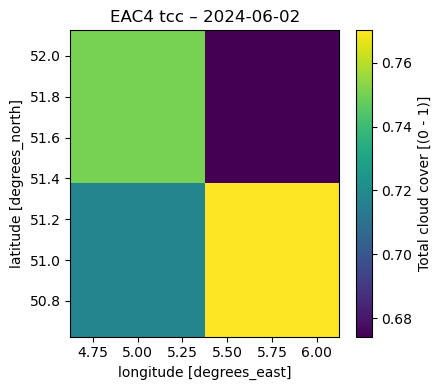

In [4]:
example_date_eac4 = date(2024, 6, 2)
test_file_eac4 = download_cams_daily(example_date_eac4, mode="reanalysis")

ds_eac4 = xr.open_dataset(test_file_eac4)
print(ds_eac4)

plt.figure(figsize=(4.5, 4))
ds_eac4["tcc"].isel(time=0).plot()
plt.title(f"EAC4 tcc – {example_date_eac4}")
plt.tight_layout()
plt.show()

ds_eac4.close()

**Visualising the EAC4 daily fields (tiny 2×2 grid)**

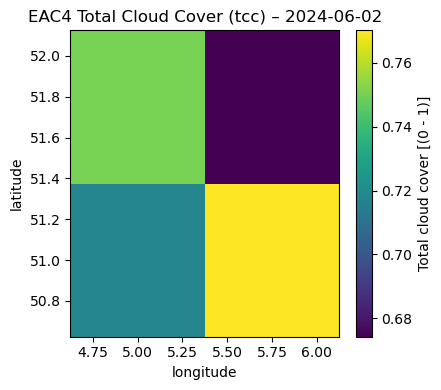

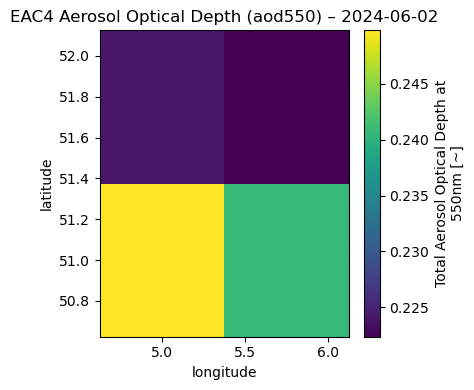

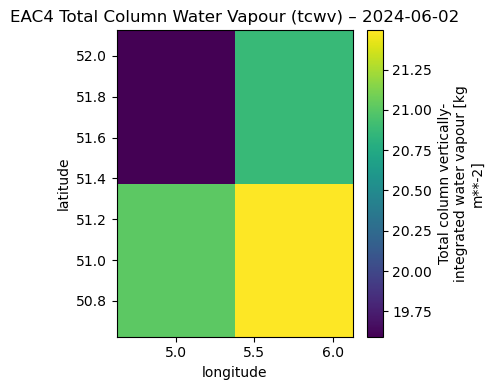

In [5]:
plt.figure(figsize=(4.5, 4))
ds_eac4["tcc"].plot()
plt.title(f"EAC4 Total Cloud Cover (tcc) – {example_date_eac4}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.5, 4))
ds_eac4["aod550"].plot()
plt.title(f"EAC4 Aerosol Optical Depth (aod550) – {example_date_eac4}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.5, 4))
ds_eac4["tcwv"].plot()
plt.title(f"EAC4 Total Column Water Vapour (tcwv) – {example_date_eac4}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

ds_eac4.close()

**Observations:**

On 2 June 2024, the EAC4 maps show a very clear 2×2 block structure. This is exactly what we expect from the EAC4 0.25° grid, because the Eindhoven box (51–52°N, 5–6°E) only contains four grid cells at that resolution. Each block represents the averaged value over one coarse model cell. Across the three variables (cloud cover, aerosol optical depth, and water vapour), we can see that each quadrant has a distinct value, with strong differences between the top-left, top-right, bottom-left, and bottom-right blocks. The patterns look sharp because the grid is coarse: the model assigns one value to the whole 0.25° area. For example, cloud cover is higher in the northwest and southeast quadrants, and lower in the northeast. Aerosols show the highest concentration in the bottom-left cell, and water vapour shows a similar “diagonal contrast” between moist and dry cells. These variations are expected, because EAC4 reanalysis blends satellite data with atmospheric models but still operates on a coarse grid that simplifies the spatial patterns.

## 5. Example: NRT analysis for one day (2025-01-01)

In [6]:
example_date_nrt = date(2025, 1, 1)
download_cams_daily(example_date_nrt, mode="forecast")

test_file_nrt = CAMS_DIR / f"cams_nrt_{example_date_nrt:%Y-%m-%d}_daily.nc"
ds_nrt = xr.open_dataset(test_file_nrt)

print(ds_nrt)
print("\nData variables:", list(ds_nrt.data_vars))

for var in ["aod550", "tcwv"]:
    if var in ds_nrt:
        print(f"\n{var}:")
        print("  min :", float(ds_nrt[var].min()))
        print("  max :", float(ds_nrt[var].max()))
        print("  mean:", float(ds_nrt[var].mean()))

<xarray.Dataset> Size: 128B
Dimensions:  (time: 1, lat: 3, lon: 3)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-01-01
  * lat      (lat) float64 24B 51.8 51.4 51.0
  * lon      (lon) float64 24B 5.0 5.4 5.8
Data variables:
    tcwv     (time, lat, lon) float32 36B ...
    aod550   (time, lat, lon) float32 36B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-11T08:48 GRIB to CDM+CF via cfgrib-0.9.1...

Data variables: ['tcwv', 'aod550']

aod550:
  min : 0.11787046492099762
  max : 0.1659127026796341
  mean: 0.1490422487258911

tcwv:
  min : 14.598833084106445
  max : 19.069643020629883
  mean: 16.907928466796875


**Visualising the NRT daily fields (3×3 grid)**

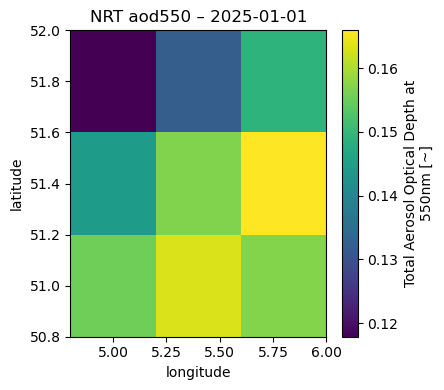

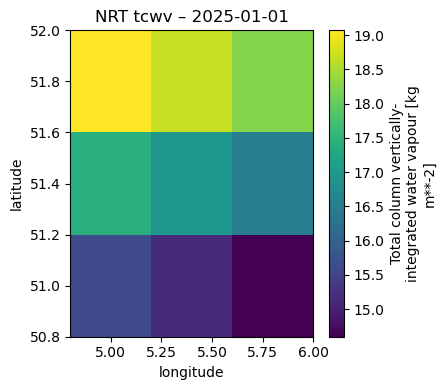

In [7]:
plt.figure(figsize=(4.5, 4))
ds_nrt["aod550"].plot()
plt.title(f"NRT aod550 – {example_date_nrt}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.5, 4))
ds_nrt["tcwv"].plot()
plt.title(f"NRT tcwv – {example_date_nrt}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

ds_nrt.close()

**Observations:**

On 1 January 2025, the NRT maps show a 3×2 block structure (6 blocks) instead of four. This is because NRT uses a finer 0.1° grid, which fits more grid points inside the same Eindhoven domain. That means each block represents a smaller area, giving a more detailed picture than the EAC4 reanalysis. The spatial patterns are therefore more varied: aerosol optical depth shows smoother transitions from low (northwest) to high (southeast), and water vapour decreases clearly from north to south. The values are also different from the EAC4 day because this is a winter date — aerosols and water vapour are naturally lower in January, and atmospheric conditions change much more quickly day-to-day. The finer grid also captures small regional differences, which creates the “6-block mosaic” instead of the simpler 4-block pattern.

## 6. Download for whole date range

In [8]:
def download_cams_range(start: date, end: date, mode: str):
    """
    Download CAMS daily data for all days between start and end (inclusive).
    """
    d = start
    while d <= end:
        print(f"\n=== {d} ({mode}) ===")
        download_cams_daily(d, mode=mode)
        d += timedelta(days=1)

In [9]:
# 2024: full year of EAC4 reanalysis
download_cams_range(
    date(2024, 1, 1),
    date(2024, 12, 31),
    mode="reanalysis"
)


=== 2024-01-01 (reanalysis) ===

=== 2024-01-02 (reanalysis) ===

=== 2024-01-03 (reanalysis) ===

=== 2024-01-04 (reanalysis) ===

=== 2024-01-05 (reanalysis) ===

=== 2024-01-06 (reanalysis) ===

=== 2024-01-07 (reanalysis) ===

=== 2024-01-08 (reanalysis) ===

=== 2024-01-09 (reanalysis) ===

=== 2024-01-10 (reanalysis) ===

=== 2024-01-11 (reanalysis) ===

=== 2024-01-12 (reanalysis) ===

=== 2024-01-13 (reanalysis) ===

=== 2024-01-14 (reanalysis) ===

=== 2024-01-15 (reanalysis) ===

=== 2024-01-16 (reanalysis) ===

=== 2024-01-17 (reanalysis) ===

=== 2024-01-18 (reanalysis) ===

=== 2024-01-19 (reanalysis) ===

=== 2024-01-20 (reanalysis) ===

=== 2024-01-21 (reanalysis) ===

=== 2024-01-22 (reanalysis) ===

=== 2024-01-23 (reanalysis) ===

=== 2024-01-24 (reanalysis) ===

=== 2024-01-25 (reanalysis) ===

=== 2024-01-26 (reanalysis) ===

=== 2024-01-27 (reanalysis) ===

=== 2024-01-28 (reanalysis) ===

=== 2024-01-29 (reanalysis) ===

=== 2024-01-30 (reanalysis) ===

=== 2024-

In [10]:
# 2025 Q1: NRT analyses (if available on ADS)
download_cams_range(
    date(2025, 1, 1),
    date(2025, 3, 31),
    mode="forecast"
)


=== 2025-01-01 (forecast) ===

=== 2025-01-02 (forecast) ===

=== 2025-01-03 (forecast) ===

=== 2025-01-04 (forecast) ===

=== 2025-01-05 (forecast) ===

=== 2025-01-06 (forecast) ===

=== 2025-01-07 (forecast) ===

=== 2025-01-08 (forecast) ===

=== 2025-01-09 (forecast) ===

=== 2025-01-10 (forecast) ===

=== 2025-01-11 (forecast) ===

=== 2025-01-12 (forecast) ===

=== 2025-01-13 (forecast) ===

=== 2025-01-14 (forecast) ===

=== 2025-01-15 (forecast) ===

=== 2025-01-16 (forecast) ===

=== 2025-01-17 (forecast) ===

=== 2025-01-18 (forecast) ===

=== 2025-01-19 (forecast) ===

=== 2025-01-20 (forecast) ===

=== 2025-01-21 (forecast) ===

=== 2025-01-22 (forecast) ===

=== 2025-01-23 (forecast) ===

=== 2025-01-24 (forecast) ===

=== 2025-01-25 (forecast) ===

=== 2025-01-26 (forecast) ===

=== 2025-01-27 (forecast) ===

=== 2025-01-28 (forecast) ===

=== 2025-01-29 (forecast) ===

=== 2025-01-30 (forecast) ===

=== 2025-01-31 (forecast) ===

=== 2025-02-01 (forecast) ===

=== 202

## 7. Quality check for all daily CAMS files

We quickly verify that:

- All files exist for the period
- Variables are present with the expected names
- Values are in a reasonable physical range

In [11]:
from pathlib import Path
import xarray as xr
import numpy as np 
CAMS_DIR = Path("data/CAMS_Daily")

# Daily files (already averaged in previous steps)
eac4_files = sorted(CAMS_DIR.glob("cams_eac4_*_daily.nc"))
nrt_files  = sorted(CAMS_DIR.glob("cams_nrt_*_daily.nc"))

print(f"EAC4 daily files : {len(eac4_files)}")
print(f"NRT  daily files : {len(nrt_files)}")

def quick_stats(files, vars_expected, label):
    """
    Loop through a list of daily files and print
    global min/max per variable (over all days).
    """
    if not files:
        print(f"⚠ No files found for {label}")
        return
    
    global_min = {v: np.inf for v in vars_expected}
    global_max = {v: -np.inf for v in vars_expected}
    
    for f in files:
        ds = xr.open_dataset(f)
        for v in vars_expected:
            if v not in ds.data_vars:
                raise KeyError(f"{label}: variable '{v}' missing in {f.name}")
            vmin = float(ds[v].min())
            vmax = float(ds[v].max())
            global_min[v] = min(global_min[v], vmin)
            global_max[v] = max(global_max[v], vmax)
        ds.close()
    
    print(f"\n[{label}] Global min/max across {len(files)} files:")
    for v in vars_expected:
        print(f"  {v:6s}  min = {global_min[v]:8.3f}   max = {global_max[v]:8.3f}")

# EAC4: tcc, aod550, tcwv
quick_stats(eac4_files, ["tcc", "aod550", "tcwv"], label="EAC4 (reanalysis)")

# NRT: only aod550 + tcwv
quick_stats(nrt_files, ["aod550", "tcwv"], label="NRT (forecast)")

# Check time inside ONE daily file
one = xr.open_dataset(eac4_files[0])
print(one)
print("Time values:", one.time.values)
one.close()

EAC4 daily files : 366
NRT  daily files : 90

[EAC4 (reanalysis)] Global min/max across 366 files:
  tcc     min =    0.000   max =    1.000
  aod550  min =    0.013   max =    0.600
  tcwv    min =    2.585   max =   42.174

[NRT (forecast)] Global min/max across 90 files:
  aod550  min =    0.030   max =    0.569
  tcwv    min =    4.273   max =   23.228
<xarray.Dataset> Size: 88B
Dimensions:  (time: 1, lat: 2, lon: 2)
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-01-01
  * lat      (lat) float64 16B 51.75 51.0
  * lon      (lon) float64 16B 5.0 5.75
Data variables:
    tcc      (time, lat, lon) float32 16B ...
    aod550   (time, lat, lon) float32 16B ...
    tcwv     (time, lat, lon) float32 16B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    

## 8. Reproject CAMS to the SARAH 0.05° grid

Now we remap each daily CAMS file onto the same 20×20 SARAH grid you used for SARAH/DEM/S2.
We use the first SARAH SIS slice as a template.

In [12]:
import rioxarray as rxr

BASE_DIR = Path("data")
SARAH_MERGED_FILE = BASE_DIR / "SARAH3" / "sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc"

# Where we save the CAMS files aligned to SARAH grid
CAMS_SARAH_DIR = CAMS_DIR / "sarah_grid"
CAMS_SARAH_DIR.mkdir(parents=True, exist_ok=True)

print("SARAH merged file:", SARAH_MERGED_FILE.resolve())
print("CAMS SARAH-aligned output:", CAMS_SARAH_DIR.resolve())

# Load SARAH template grid (lat/lon 20x20)
sarah_ds = xr.open_dataset(SARAH_MERGED_FILE)
template = sarah_ds["SIS"].isel(time=0)

# Prepare template for rioxarray
template_rio = (
    template
    .rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    .rio.write_crs("EPSG:4326", inplace=False)
)

def regrid_cams_to_sarah(in_path: Path, mode: str, force: bool = False) -> Path:
    """
    Reproject a daily CAMS file to the SARAH 0.05° grid, preserving the real time coordinate.
    Output dims will be (time, lat, lon) to match SARAH.
    """
    out_path = CAMS_SARAH_DIR / in_path.name

    if out_path.exists() and not force:
        return out_path

    ds = xr.open_dataset(in_path)

    # Ensure coordinate names are 'lat' and 'lon'
    rename_coords = {}
    if "latitude" in ds.coords:  rename_coords["latitude"] = "lat"
    if "longitude" in ds.coords: rename_coords["longitude"] = "lon"
    if rename_coords:
        ds = ds.rename(rename_coords)

    # CAMS daily files should have time=1 already
    if "time" not in ds.dims:
        raise ValueError(f"No time dimension found in {in_path.name}")

    # Prepare for rioxarray reprojection
    ds_rio = (
        ds
        .rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
        .rio.write_crs("EPSG:4326", inplace=False)
    )

    # Reproject each variable to SARAH grid
    out_vars = {}
    for v in ds_rio.data_vars:
        if v == "spatial_ref":
            continue
        da = ds_rio[v]
        da_rg = da.rio.reproject_match(template_rio)

        # da_rg dims are usually (time, y, x). Convert to (time, lat, lon)
        da_rg = da_rg.rename({"y": "lat", "x": "lon"})
        da_rg = da_rg.assign_coords(lat=template.lat.values, lon=template.lon.values)

        out_vars[v] = da_rg

    ds_out = xr.Dataset(out_vars)
    ds_out.attrs.update(ds.attrs)

    ds_out.to_netcdf(out_path)

    ds.close()
    ds_out.close()

    return out_path

# Apply to all daily files
from tqdm import tqdm

print("\nRegridding EAC4 daily files to SARAH grid (FORCE rebuild) ...")
for f in tqdm(eac4_files):
    regrid_cams_to_sarah(f, mode="reanalysis", force=True)

print("\nRegridding NRT daily files to SARAH grid (FORCE rebuild) ...")
for f in tqdm(nrt_files):
    regrid_cams_to_sarah(f, mode="forecast", force=True)

sarah_ds.close()
print("\n✅ All CAMS daily files regridded to SARAH 0.05° grid.")


SARAH merged file: C:\Users\Student\Desktop\SIS\data\SARAH3\sarah3_sis_eindhoven_0.05_2024-01-01_2025-04-01.nc
CAMS SARAH-aligned output: C:\Users\Student\Desktop\SIS\data\CAMS_Daily\sarah_grid

Regridding EAC4 daily files to SARAH grid (FORCE rebuild) ...


100%|████████████████████████████████████████████████████████████████████████████████| 366/366 [00:27<00:00, 13.28it/s]



Regridding NRT daily files to SARAH grid (FORCE rebuild) ...


100%|██████████████████████████████████████████████████████████████████████████████████| 90/90 [00:05<00:00, 15.18it/s]


✅ All CAMS daily files regridded to SARAH 0.05° grid.


## 9. Merge all SARAH-aligned CAMS days into time series

Finally, we concatenate all regridded daily files along time to create clean CAMS time series.

In [13]:
aligned_eac4_files = sorted(CAMS_SARAH_DIR.glob("cams_eac4_*_daily.nc"))
aligned_nrt_files  = sorted(CAMS_SARAH_DIR.glob("cams_nrt_*_daily.nc"))

print("Aligned EAC4 files:", len(aligned_eac4_files))
print("Aligned NRT  files:", len(aligned_nrt_files))

CAMS_SERIES_DIR = BASE_DIR / "CAMS"
CAMS_SERIES_DIR.mkdir(parents=True, exist_ok=True)

EAC4_SERIES_FILE = CAMS_SERIES_DIR / "cams_eac4_ehv_0.05_daily.nc"
NRT_SERIES_FILE  = CAMS_SERIES_DIR / "cams_nrt_ehv_0.05_daily.nc"

def save_series(files, out_file: Path, label: str):
    if not files:
        print(f"⚠ No files found for {label}")
        return

    # Use by_coords so xarray stacks using each file's time coordinate
    ds = xr.open_mfdataset(files, combine="by_coords", parallel=False)
    ds = ds.sortby("time")

    tmp = out_file.with_suffix(".tmp.nc")
    if tmp.exists():
        tmp.unlink()

    ds.to_netcdf(tmp)
    ds.close()

    if out_file.exists():
        out_file.unlink()
    tmp.rename(out_file)

    print(f"✅ Saved {label} series to: {out_file}")

save_series(aligned_eac4_files, EAC4_SERIES_FILE, "EAC4")
save_series(aligned_nrt_files,  NRT_SERIES_FILE,  "NRT")

Aligned EAC4 files: 366
Aligned NRT  files: 90
✅ Saved EAC4 series to: data\CAMS\cams_eac4_ehv_0.05_daily.nc
✅ Saved NRT series to: data\CAMS\cams_nrt_ehv_0.05_daily.nc


## 10. Conclusion

This notebook successfully prepares CAMS atmospheric variables (EAC4 reanalysis and NRT forecasts) for use in the solar radiation modelling framework. The workflow achieved the following:

- Downloaded and validated CAMS data:
    - Extracted daily means for cloud cover (tcc), aerosol optical depth (aod550) and water vapour (tcwv).
    - Checked all files for completeness and physical consistency.
    - The variable ranges match expected atmospheric behaviour over the Netherlands.

- Regridded CAMS to the SARAH 0.05° grid:
    - Both EAC4 (2×2 grid) and NRT (3×3 grid) were resampled to the 20×20 SARAH grid.
    - Spatial alignment with SARAH, DEM and Sentinel-2 is now exact.

- Created clean daily time-series datasets
    - Merged 366 EAC4 and 90 NRT days into two temporally continuous NetCDF files.
    - These files share identical (time, lat, lon) coordinates with SARAH and DEM.

Together, these steps complete the CAMS preprocessing pipeline, producing datasets that can now be seamlessly integrated with SARAH-3 solar radiation, DEM terrain features and Sentinel-2 monthly composites for analysis and machine-learning modeling.

=> The CAMS dataset is now fully ready for the next stage: fusion, feature engineering and model development.